# Static CBED Benchmark — Au [100]

Static-crystal CBED patterns for Au [100] (200 keV),
comparing all 4 propagation methods against a Forward Square-Root Propagator reference.

- **Methods**: Fresnel (Paraxial), Angular Spectrum (Non-Paraxial), WPM, Forward Square-Root Propagator (reference)
- **Crystal**: Au [100], no thermal displacements
- **Probe**: 6.2 mrad convergent beam
- **Thickness**: target 10 nm using repeated unit cells along z
- **Metric**: Relative L2 error of CBED pattern vs the Forward Square-Root Propagator

In [1]:
%matplotlib inline

import os
from time import perf_counter
import functools

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".4"

import abtem
import cupy
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from ase.build import bulk
from matplotlib.colors import LogNorm

from wide_angle_propagation.propagation_methods import (
    electron_refractive_index,
    energy2wavelength,
    fresnel_propagation_kernel,
    angular_spectrum_propagation_kernel,
    simulate_fresnel_as,
    simulate_wpm,
    simulate_wpm_jit,
 )
from wide_angle_propagation.propagation_methods import _lanczos_expsqrt

abtem.config.set({"device": "gpu"})
abtem.config.set({"precision": "float64"})
jax.config.update("jax_enable_x64", True)

## Crystal, probe, and potential setup

Au [100] static crystal from FCC bulk cell.
10 nm thickness is set only by repeating the unit cell along z.

In [2]:
# --- Runtime mode ---
quick_run = True  # Set False for full-resolution benchmark run
if quick_run:
    n_cells_xy = (2, 2)
    n_slices_per_cell = 4
    lanczos_m = 24
    run_wpm = False
else:
    n_cells_xy = (3, 3)
    n_slices_per_cell = 16
    lanczos_m = 80
    run_wpm = True

# --- Parameters ---
energy = 200e3
a_Au = 4.076
semiangle_mrad = 6.2
target_thickness_ang = 100.0  # 10 nm

# --- Build Au [100] cubic unit cell ---
unit_cell = bulk("Au", "fcc", a=a_Au, cubic=True)
unit_cell.pbc = [True, True, True]

# Thickness is set by integer unit-cell repeats only
z_period = float(unit_cell.cell[2, 2])
n_cells_z = int(np.ceil(target_thickness_ang / z_period))
supercell = unit_cell * (*n_cells_xy, n_cells_z)

cell_thickness = z_period
slice_dz = cell_thickness / n_slices_per_cell
total_thickness = float(supercell.cell[2, 2])
n_total_slices = n_cells_z * n_slices_per_cell

# Reference potential (for grid matching)
potential_ref = abtem.Potential(
    supercell, sampling=0.1, slice_thickness=slice_dz,
    projection="finite", parametrization="lobato",
)
gpts = tuple(potential_ref.gpts)

# CBED probe
probe = abtem.Probe(energy=energy, semiangle_cutoff=semiangle_mrad)
probe.grid.match(potential_ref)
probe_array = jnp.array(cupy.asnumpy(probe.build(lazy=False).array))
sampling = (float(probe.grid.sampling[0]), float(probe.grid.sampling[1]))

# Propagation kernels
fk = jnp.array(fresnel_propagation_kernel(*gpts, sampling, z=slice_dz, energy=energy))
ak = jnp.array(angular_spectrum_propagation_kernel(*gpts, sampling, z=slice_dz, energy=energy))

wavelength = energy2wavelength(energy)
print(f"Mode: {'quick' if quick_run else 'full'}")
print("Crystal: Au [100] (static, no thermal displacements)")
print(f"Supercell: {n_cells_xy[0]}x{n_cells_xy[1]}x{n_cells_z}, {len(supercell)} atoms")
lx, ly, lz = supercell.cell.lengths()
print(f"Cell: {lx:.1f} x {ly:.1f} x {lz:.1f} A")
print(f"Energy: {energy/1e3:.0f} keV, lambda = {wavelength:.4f} A")
print(f"Grid: {gpts}, sampling = ({sampling[0]:.4f}, {sampling[1]:.4f}) A")
print(f"Slices: {n_total_slices} total ({n_slices_per_cell}/cell), dz = {slice_dz:.4f} A")
print(f"Target thickness: {target_thickness_ang:.1f} A (10 nm)")
print(f"Total thickness from repeats: {total_thickness:.1f} A")
print(f"CBED probe: {semiangle_mrad} mrad")
print(f"Lanczos Krylov order m: {lanczos_m}")
print(f"Run WPM: {run_wpm}")

Mode: quick
Crystal: Au [100] (static, no thermal displacements)
Supercell: 2x2x25, 400 atoms
Cell: 8.2 x 8.2 x 101.9 A
Energy: 200 keV, lambda = 0.0251 A
Grid: (82, 82), sampling = (0.0994, 0.0994) A
Slices: 100 total (4/cell), dz = 1.0190 A
Target thickness: 100.0 A (10 nm)
Total thickness from repeats: 101.9 A
CBED probe: 6.2 mrad
Lanczos Krylov order m: 24
Run WPM: False


## KG FWD Lanczos propagator (lightweight runtime mode)

Uses a simple Python slice loop to avoid heavy first-time JIT compilation.
This is typically faster for interactive notebook reruns and parameter tuning.

In [3]:
def simulate_kg_fwd_lanczos(pot_arr, psi_0, dz, E, samp, lanczos_m=48):
    """Non-jitted KG forward Lanczos propagation with a Python loop."""
    ny, nx = psi_0.shape
    k0_sq = (2 * jnp.pi / energy2wavelength(E)) ** 2
    dy, dx = samp
    fy = jnp.fft.fftfreq(ny, d=dy)
    fx = jnp.fft.fftfreq(nx, d=dx)
    Fx, Fy = jnp.meshgrid(fx, fy)
    kp_sq = (2 * jnp.pi * Fy) ** 2 + (2 * jnp.pi * Fx) ** 2
    n_sq_all = jax.vmap(lambda V: electron_refractive_index(V, E) ** 2)(pot_arr)

    state = jnp.fft.fft2(jnp.asarray(psi_0, dtype=jnp.complex128)).ravel() / (ny * nx)
    for n_sq in n_sq_all:
        n_sq = n_sq.reshape(ny, nx)

        def matvec(v):
            vg = v.reshape(ny, nx)
            conv = jnp.fft.fft2(n_sq * jnp.fft.ifft2(vg))
            return (k0_sq * conv - kp_sq * vg).ravel()

        state = _lanczos_expsqrt(matvec, state, dz, lanczos_m)

    exit_k = state.reshape(ny, nx)
    exit_wave = jnp.fft.ifft2(exit_k) * (ny * nx)
    return np.asarray(exit_wave)

print("Lanczos propagator defined (non-jitted Python loop).")

Lanczos propagator defined (non-jitted Python loop).


## Static-crystal propagation

Build one Au [100] potential and run selected methods once.
This keeps method comparison parity with the Si benchmark outputs.

In [4]:
method_names = ["Fresnel MS", "Angular Spectrum", "KG FWD Lanczos"]
if run_wpm:
    method_names.insert(2, "WPM")

dp_avg = {}
exit_waves = {}
method_timings = {name: 0.0 for name in method_names}

pot_static = abtem.Potential(
    supercell, gpts=gpts, slice_thickness=slice_dz,
    projection="finite", parametrization="lobato",
)
pot_arr = jnp.array(cupy.asnumpy(pot_static.build(lazy=False).array / slice_dz))
del pot_static
cupy.get_default_memory_pool().free_all_blocks()

# Fresnel MS
t0 = perf_counter()
ew_f, _, _ = simulate_fresnel_as(pot_arr, probe_array, fk, slice_dz, energy)
method_timings["Fresnel MS"] += perf_counter() - t0

# Angular Spectrum MS
t0 = perf_counter()
ew_a, _, _ = simulate_fresnel_as(pot_arr, probe_array, ak, slice_dz, energy)
method_timings["Angular Spectrum"] += perf_counter() - t0

method_results = {
    "Fresnel MS": ew_f,
    "Angular Spectrum": ew_a,
}

# WPM (optional in quick mode)
if run_wpm:
    t0 = perf_counter()
    if quick_run:
        ew_w, _, _ = simulate_wpm(pot_arr, probe_array, slice_dz, energy, sampling)
    else:
        ew_w, _, _ = simulate_wpm_jit(pot_arr, probe_array, slice_dz, energy, sampling)
    method_timings["WPM"] += perf_counter() - t0
    method_results["WPM"] = ew_w

# KG FWD Lanczos (non-jitted)
t0 = perf_counter()
ew_l = simulate_kg_fwd_lanczos(
    pot_arr, probe_array, slice_dz, energy, sampling, lanczos_m=lanczos_m
)
method_timings["KG FWD Lanczos"] += perf_counter() - t0
method_results["KG FWD Lanczos"] = ew_l

# Store DP and exit waves
for name in method_names:
    ew = method_results[name]
    dp_i = np.abs(np.fft.fftshift(np.fft.fft2(np.asarray(ew)))) ** 2
    dp_avg[name] = dp_i
    exit_waves[name] = np.asarray(ew)

del pot_arr
print(f"\nStatic-crystal run complete ({len(method_names)} methods).")
print("\nTotal timings:")
for name in method_names:
    print(f"  {name:<22s} {method_timings[name]:>8.1f}s")


Static-crystal run complete (3 methods).

Total timings:
  Fresnel MS                  1.3s
  Angular Spectrum            0.3s
  KG FWD Lanczos             30.6s


## CBED patterns

Diffraction intensities for a static Au [100] crystal.
Displayed on a log scale.

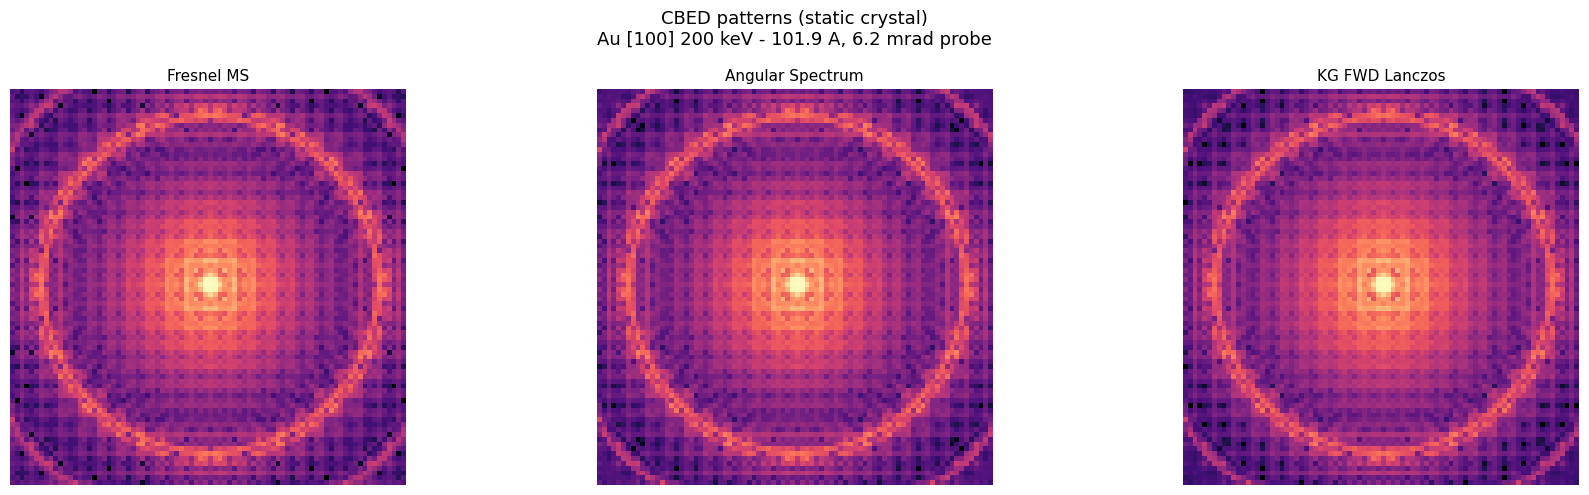

In [ ]:
display_names = {
    "Fresnel MS": "Fresnel (Paraxial)",
    "Angular Spectrum": "Angular Spectrum (Non-Paraxial)",
    "WPM": "WPM (Wide-angle, local n)",
    "KG FWD Lanczos": "Forward Square-Root Propagator",
}

fig, axes = plt.subplots(1, len(method_names), figsize=(6 * len(method_names), 5))

for j, name in enumerate(method_names):
    dp = dp_avg[name]
    dp_n = dp / dp.max() if dp.max() > 0 else dp
    axes[j].imshow(dp_n, norm=LogNorm(vmin=1e-8, vmax=1), cmap="magma", origin="lower")
    axes[j].set_title(display_names.get(name, name), fontsize=11)
    axes[j].axis("off")

fig.suptitle(
    f"CBED patterns (static crystal)\n"
    f"Au [100] {energy/1e3:.0f} keV - {total_thickness:.1f} A, {semiangle_mrad} mrad probe",
    fontsize=13,
 )
plt.tight_layout()
plt.show()

## Exit wave comparison

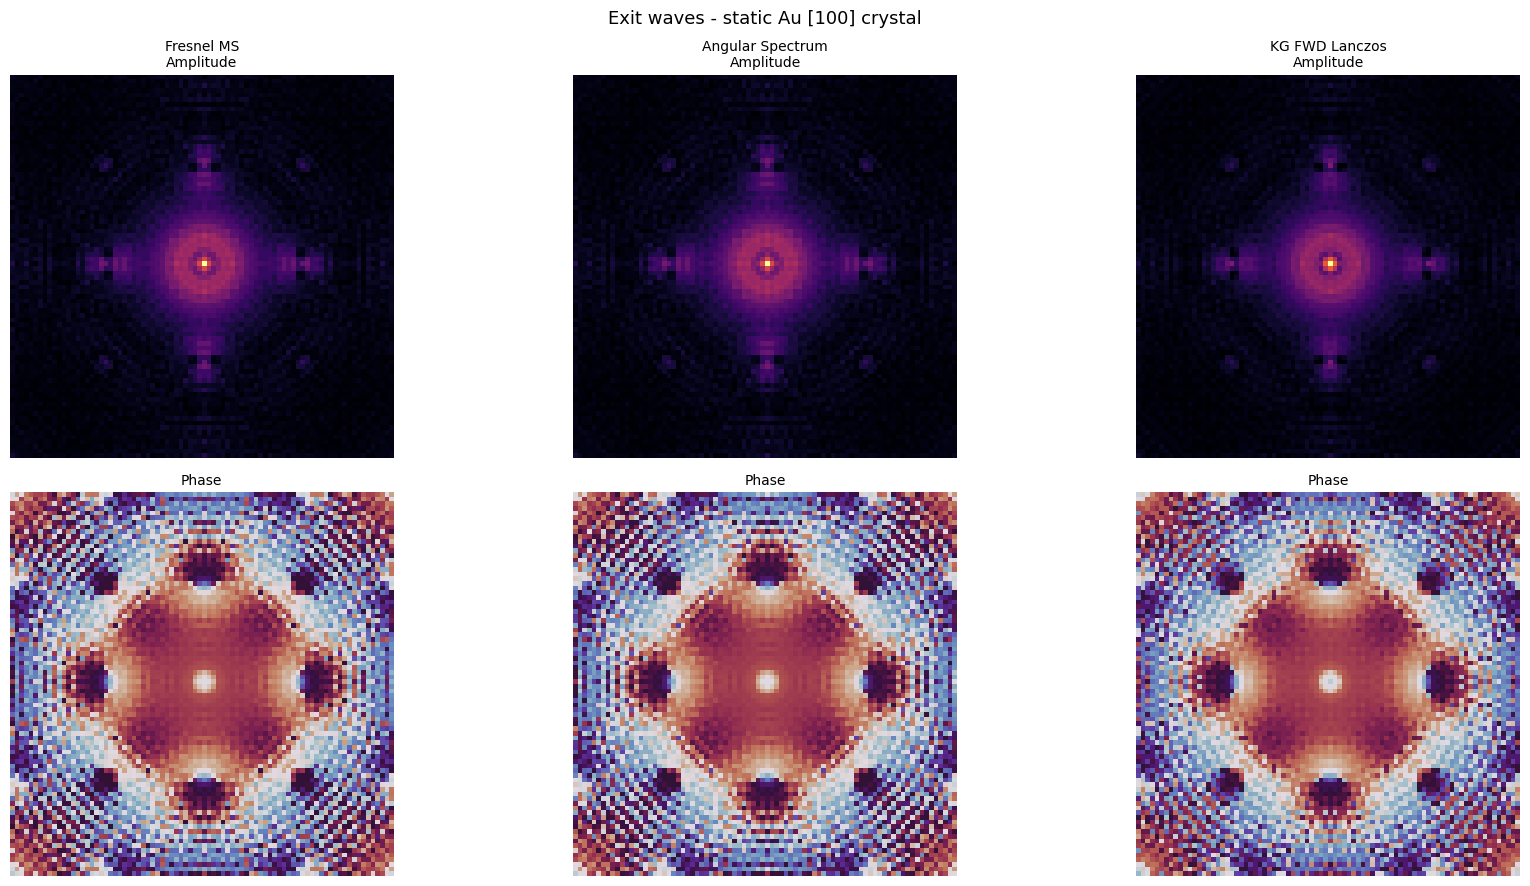

In [ ]:
display_names = {
    "Fresnel MS": "Fresnel (Paraxial)",
    "Angular Spectrum": "Angular Spectrum (Non-Paraxial)",
    "WPM": "WPM (Wide-angle, local n)",
    "KG FWD Lanczos": "Forward Square-Root Propagator",
}

fig, axes = plt.subplots(2, len(method_names), figsize=(6 * len(method_names), 9))

for j, name in enumerate(method_names):
    ew = exit_waves[name]
    amp = np.abs(ew)
    phase = np.angle(ew)

    axes[0, j].imshow(amp, cmap="inferno", origin="lower")
    axes[0, j].set_title(f"{display_names.get(name, name)}\nAmplitude", fontsize=10)
    axes[0, j].axis("off")

    axes[1, j].imshow(phase, cmap="twilight", origin="lower", vmin=-np.pi, vmax=np.pi)
    axes[1, j].set_title("Phase", fontsize=10)
    axes[1, j].axis("off")

fig.suptitle("Exit waves - static Au [100] crystal", fontsize=13)
plt.tight_layout()
plt.show()

## Error analysis relative to KG FWD Lanczos

Difference maps of diffraction patterns, plus RMSE and relative $L^2$ error.

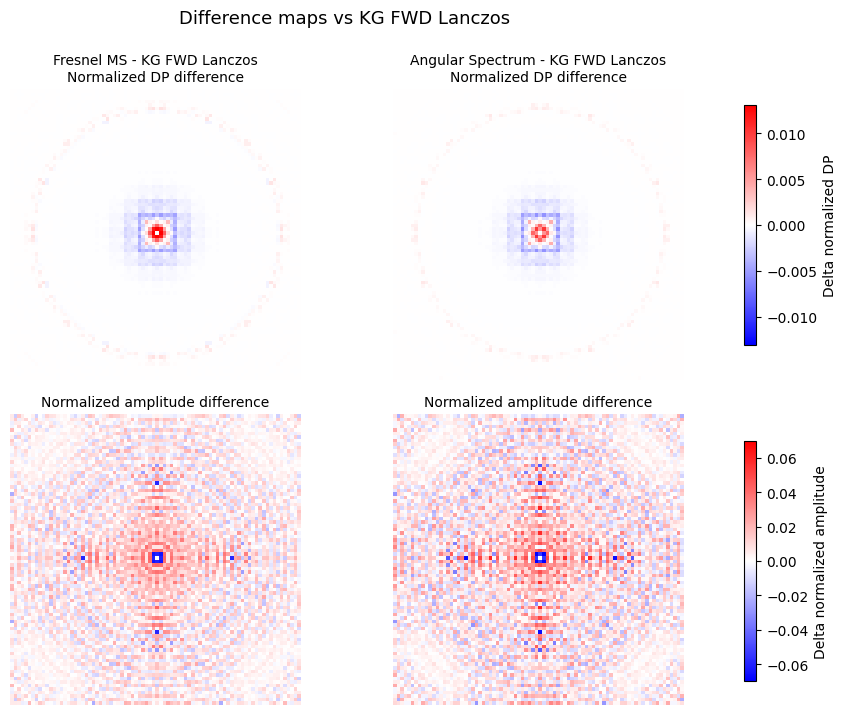


Method                            RMSE       Rel L2     Time (s)
----------------------------------------------------------------
Fresnel MS                6.663991e-04 2.114652e-02         1.29
Angular Spectrum          5.734138e-04 1.819587e-02         0.30
KG FWD Lanczos (ref)      0.000000e+00 0.000000e+00        30.57


In [ ]:
display_names = {
    "Fresnel MS": "Fresnel (Paraxial)",
    "Angular Spectrum": "Angular Spectrum (Non-Paraxial)",
    "WPM": "WPM (Wide-angle, local n)",
    "KG FWD Lanczos": "Forward Square-Root Propagator",
}

ref_name = "KG FWD Lanczos"
ref_display_name = display_names.get(ref_name, ref_name)

dp_ref = dp_avg[ref_name]
dp_ref_norm = dp_ref / dp_ref.max() if dp_ref.max() > 0 else dp_ref

amp_ref = np.abs(exit_waves[ref_name])
amp_ref_norm = amp_ref / amp_ref.max() if amp_ref.max() > 0 else amp_ref

compare_names = [n for n in method_names if n != ref_name]

dp_diffs, amp_diffs = [], []
for name in compare_names:
    dp_n = dp_avg[name] / dp_avg[name].max() if dp_avg[name].max() > 0 else dp_avg[name]
    amp_n = np.abs(exit_waves[name])
    amp_n = amp_n / amp_n.max() if amp_n.max() > 0 else amp_n

    dp_diffs.append(dp_n - dp_ref_norm)
    amp_diffs.append(amp_n - amp_ref_norm)

dp_vlim = max(max(abs(d.min()), abs(d.max())) for d in dp_diffs)
amp_vlim = max(max(abs(d.min()), abs(d.max())) for d in amp_diffs)
dp_vlim = max(dp_vlim, 1e-6)
amp_vlim = max(amp_vlim, 1e-6)

fig, axes = plt.subplots(2, len(compare_names), figsize=(5 * len(compare_names), 8))
if len(compare_names) == 1:
    axes = np.array([[axes[0]], [axes[1]]])

im_dp = im_amp = None
for j, name in enumerate(compare_names):
    display_name = display_names.get(name, name)
    im_dp = axes[0, j].imshow(
        dp_diffs[j], cmap="bwr", origin="lower", vmin=-dp_vlim, vmax=dp_vlim
    )
    axes[0, j].set_title(f"{display_name} - {ref_display_name}\nNormalized DP difference", fontsize=10)
    axes[0, j].axis("off")

    im_amp = axes[1, j].imshow(
        amp_diffs[j], cmap="bwr", origin="lower", vmin=-amp_vlim, vmax=amp_vlim
    )
    axes[1, j].set_title("Normalized amplitude difference", fontsize=10)
    axes[1, j].axis("off")

fig.subplots_adjust(right=0.88, wspace=0.03, hspace=0.12)

cax1 = fig.add_axes([0.90, 0.56, 0.012, 0.30])
cbar1 = fig.colorbar(im_dp, cax=cax1)
cbar1.set_label("Delta normalized DP")

cax2 = fig.add_axes([0.90, 0.14, 0.012, 0.30])
cbar2 = fig.colorbar(im_amp, cax=cax2)
cbar2.set_label("Delta normalized amplitude")

fig.suptitle(f"Difference maps vs {ref_display_name}", fontsize=13)
plt.show()

print(f"\n{'Method':<40} {'RMSE':>12} {'Rel L2':>12} {'Time (s)':>12}")
print("-" * 78)
for name in method_names:
    dp_n = dp_avg[name] / dp_avg[name].max() if dp_avg[name].max() > 0 else dp_avg[name]
    diff = dp_n - dp_ref_norm
    rmse = float(np.sqrt(np.mean(diff**2)))
    rel_l2 = float(np.linalg.norm(diff) / (np.linalg.norm(dp_ref_norm) + 1e-30))
    t = method_timings[name]
    display_name = display_names.get(name, name)
    marker = " (ref)" if name == ref_name else ""
    print(f"{display_name + marker:<40} {rmse:>12.6e} {rel_l2:>12.6e} {t:>12.2f}")

## Timing benchmark

Wall-clock time for each propagation method (single static-crystal run).

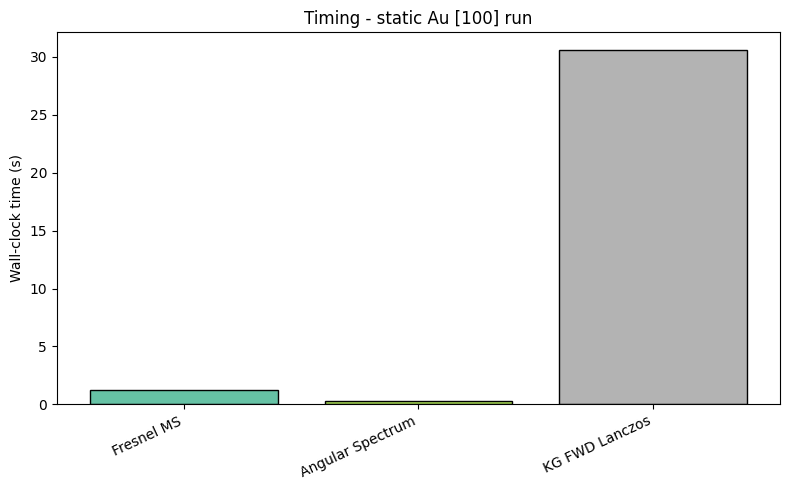


Wall-clock times:
  Fresnel MS                     1.3 s
  Angular Spectrum               0.3 s
  KG FWD Lanczos                30.6 s


In [ ]:
display_names = {
    "Fresnel MS": "Fresnel (Paraxial)",
    "Angular Spectrum": "Angular Spectrum (Non-Paraxial)",
    "WPM": "WPM (Wide-angle, local n)",
    "KG FWD Lanczos": "Forward Square-Root Propagator",
}

fig, ax = plt.subplots(figsize=(8, 5))
times = [method_timings[n] for n in method_names]
labels = [display_names.get(n, n) for n in method_names]
colors = plt.cm.Set2(np.linspace(0, 1, len(method_names)))
ax.bar(labels, times, color=colors, edgecolor="k")
ax.set_ylabel("Wall-clock time (s)")
ax.set_title("Timing - static Au [100] run")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

print("\nWall-clock times:")
for name in method_names:
    print(f"  {display_names.get(name, name):<40} {method_timings[name]:>8.1f} s")